In [3]:
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
matplotlib.rcParams["figure.figsize"] = [10,6]

In [4]:
df = pd.read_csv("bhp.csv")
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


In [5]:
df.sample(5)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
12821,Nagarbhavi,4 Bedroom,600.0,4.0,78.00,4,13000
992,Electronic City Phase II,3 BHK,1400.0,2.0,40.43,3,2887
8310,Kodichikkanahalli,2 BHK,907.0,2.0,38.50,2,4244
5426,Electronic City,2 BHK,1020.0,2.0,29.46,2,2888
5948,Doddakallasandra,3 BHK,1425.0,2.0,56.99,3,3999


In [6]:
df.price_per_sqft.describe()

count    1.320000e+04
mean     7.920337e+03
std      1.067272e+05
min      2.670000e+02
25%      4.267000e+03
50%      5.438000e+03
75%      7.317000e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

In [7]:
# Remove outliers using percentile threshold
min_threshold, max_threshold = df.price_per_sqft.quantile([0.001, 0.999])
min_threshold, max_threshold

(1366.184, 50959.36200000098)

In [8]:
df[df.price_per_sqft>max_threshold]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
345,other,3 Bedroom,11.0,3.0,74.0,3,672727
1005,other,1 BHK,15.0,1.0,30.0,1,200000
1106,other,5 Bedroom,24.0,2.0,150.0,5,625000
4044,Sarjapur Road,4 Bedroom,1.0,4.0,120.0,4,12000000
4924,other,7 BHK,5.0,7.0,115.0,7,2300000
5911,Mysore Road,1 Bedroom,45.0,1.0,23.0,1,51111
6356,Bommenahalli,4 Bedroom,2940.0,3.0,2250.0,4,76530
7012,other,1 BHK,650.0,1.0,500.0,1,76923
7575,other,1 BHK,425.0,1.0,750.0,1,176470
7799,other,4 BHK,2000.0,3.0,1063.0,4,53150


In [9]:
df[df.price_per_sqft<min_threshold]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
665,Yelahanka,3 BHK,35000.0,3.0,130.0,3,371
798,other,4 Bedroom,10961.0,4.0,80.0,4,729
1867,other,3 Bedroom,52272.0,2.0,140.0,3,267
2392,other,4 Bedroom,2000.0,3.0,25.0,4,1250
3934,other,1 BHK,1500.0,1.0,19.5,1,1300
5343,other,9 BHK,42000.0,8.0,175.0,9,416
5417,Ulsoor,4 BHK,36000.0,4.0,450.0,4,1250
5597,JP Nagar,2 BHK,1100.0,1.0,15.0,2,1363
7166,Yelahanka,1 Bedroom,26136.0,1.0,150.0,1,573
7862,JP Nagar,3 BHK,20000.0,3.0,175.0,3,875


In [11]:
df1 = df[(df.price_per_sqft<max_threshold) & (df.price_per_sqft>min_threshold)]
df.shape, df1.shape

((13200, 7), (13172, 7))

In [14]:
# Use 4 Standard Deviation to remove outliers
df1.price_per_sqft.mean()

6663.6537351958705

In [15]:
df1.price_per_sqft.std()

4141.020700174613

In [17]:
upper_limit = df1.price_per_sqft.mean() + 4 * df1.price_per_sqft.std()
upper_limit

23227.73653589432

In [18]:
lower_limit = df1.price_per_sqft.mean() - 4 * df1.price_per_sqft.std()
lower_limit

-9900.429065502582

In [19]:
df1[df1.price_per_sqft>upper_limit]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333
190,Bellandur,4 Bedroom,1200.0,5.0,325.0,4,27083
733,Cunningham Road,4 BHK,5270.0,4.0,1250.0,4,23719
760,other,9 Bedroom,600.0,9.0,190.0,9,31666
...,...,...,...,...,...,...,...
13081,other,6 Bedroom,8000.0,6.0,2800.0,6,35000
13094,other,4 Bedroom,1200.0,5.0,325.0,4,27083
13127,other,4 Bedroom,1200.0,5.0,325.0,4,27083
13185,Hulimavu,1 BHK,500.0,1.0,220.0,1,44000


In [20]:
df1[df1.price_per_sqft<lower_limit]

,location,size,total_sqft,bath,price,bhk,price_per_sqft


In [21]:
df2 = df1[(df1.price_per_sqft<upper_limit) & (df1.price_per_sqft>lower_limit)]
df2.shape

(13047, 7)

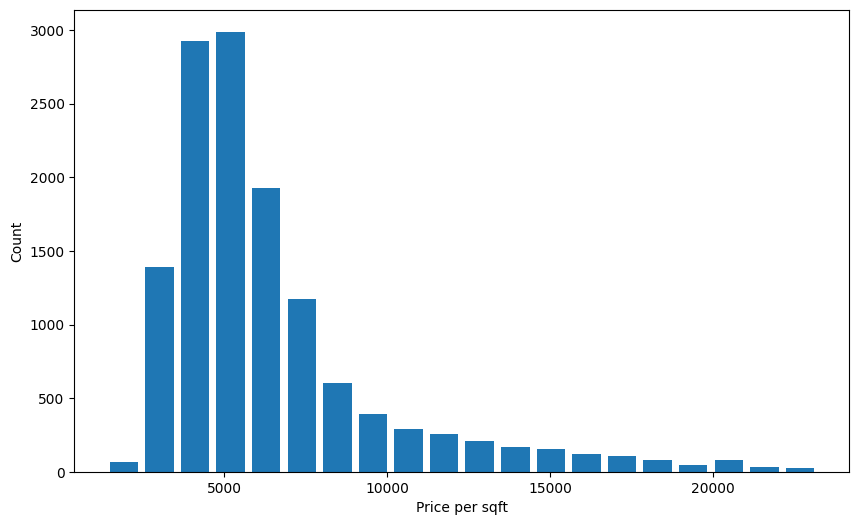

In [22]:
plt.hist(df2.price_per_sqft, bins=20, rwidth=0.8)
plt.xlabel("Price per sqft")
plt.ylabel("Count")
plt.show()

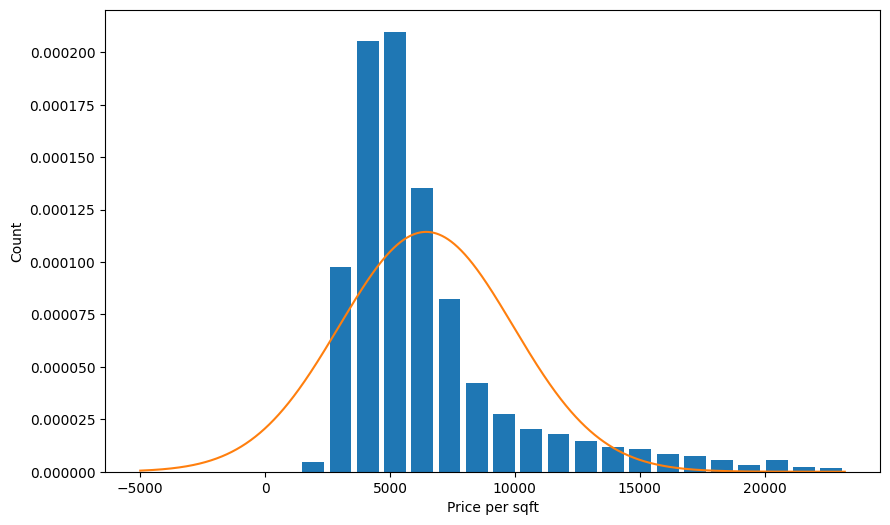

In [27]:
# Create a bell curv
from scipy.stats import norm
import numpy as np

plt.hist(df2.price_per_sqft, bins=20, rwidth=0.8, density=True)
plt.xlabel("Price per sqft")
plt.ylabel("Count")

rng = np.arange(-5000, df2.price_per_sqft.max(), 0.1)
plt.plot(rng, norm.pdf(rng, df2.price_per_sqft.mean(), df2.price_per_sqft.std()))

In [28]:
# Remove outlier using zscore
df2["zscore"] = (df2.price_per_sqft - df2.price_per_sqft.mean())/df2.price_per_sqft.std()
df2.sample(10)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13580\3050875331.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["zscore"] = (df2.price_per_sqft - df2.price_per_sqft.mean())/df2.price_per_sqft.std()


,location,size,total_sqft,bath,price,bhk,price_per_sqft,zscore
8994,Rajaji Nagar,2 BHK,1268.0,2.0,127.00,2,10015,1.022365
3472,Uttarahalli,7 Bedroom,1200.0,7.0,225.00,7,18750,3.526902
57,Murugeshpalya,6 Bedroom,1407.0,4.0,150.00,6,10660,1.207302
11927,Yelahanka,2 BHK,1175.0,2.0,67.77,2,5767,-0.195640
7394,Thubarahalli,3 BHK,1540.0,3.0,90.00,3,5844,-0.173562
10085,Attibele,3 Bedroom,1200.0,3.0,105.00,3,8750,0.659659
10605,Koramangala,2 BHK,1320.0,2.0,160.00,2,12121,1.626207
7362,Mallasandra,4 BHK,1810.0,3.0,57.00,4,3149,-0.946284
9235,Devanahalli,3 BHK,1550.0,3.0,85.00,3,5483,-0.277070
2968,Whitefield,3 BHK,3850.0,5.0,316.00,3,8207,0.503967


In [29]:
# Outliers using zscore
outliers = df2[(df2.zscore>4) | (df2.zscore<-4)]
outliers

,location,size,total_sqft,bath,price,bhk,price_per_sqft,zscore
87,Rajaji Nagar,6 Bedroom,710.0,6.0,160.0,6,22535,4.612154
408,Mahalakshmi Layout,6 Bedroom,1200.0,7.0,250.0,6,20833,4.124149
429,7th Phase JP Nagar,8 Bedroom,1200.0,8.0,250.0,8,20833,4.124149
475,other,4 BHK,1150.0,4.0,260.0,4,22608,4.633085
925,5th Phase JP Nagar,9 Bedroom,1260.0,11.0,290.0,9,23015,4.749782
...,...,...,...,...,...,...,...,...
12084,Nagarbhavi,5 Bedroom,1200.0,5.0,260.0,5,21666,4.362991
12245,5th Phase JP Nagar,8 Bedroom,1200.0,7.0,250.0,8,20833,4.124149
12321,2nd Stage Nagarbhavi,3 Bedroom,600.0,5.0,135.0,3,22500,4.602119
12368,Koramangala,4 Bedroom,2400.0,5.0,550.0,4,22916,4.721396


In [30]:
df3 = df2[(df2.zscore<4) & (df2.zscore>-4)]
df3.shape

(12961, 8)

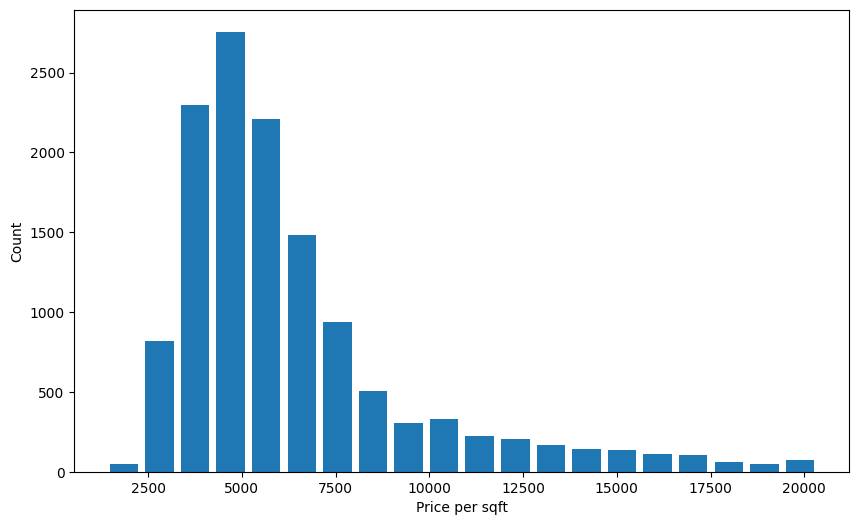

In [31]:
plt.hist(df3.price_per_sqft, bins=20, rwidth=0.8)
plt.xlabel("Price per sqft")
plt.ylabel("Count")
plt.show()

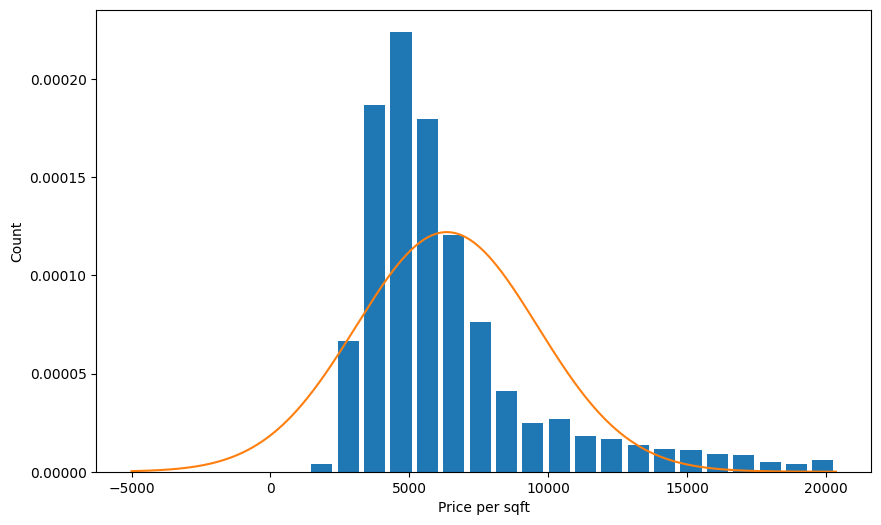

In [32]:
# Create a bell curv
from scipy.stats import norm
import numpy as np

plt.hist(df3.price_per_sqft, bins=20, rwidth=0.8, density=True)
plt.xlabel("Price per sqft")
plt.ylabel("Count")

rng = np.arange(-5000, df3.price_per_sqft.max(), 0.1)
plt.plot(rng, norm.pdf(rng, df3.price_per_sqft.mean(), df3.price_per_sqft.std()))